**12 种窗函数一览：**

| 类别 | 窗函数 | 第一旁瓣 | 主瓣宽度 | 特点 |
|------|--------|---------|---------|------|
| 基本 | Rectangular | −13 dB | 2/N | 最窄主瓣，旁瓣最高 |
| 基本 | Bartlett | −27 dB | 4/N | 三角窗，零端点 |
| 余弦 | Hann | −31 dB | 4/N | 常用通用窗 |
| 余弦 | Hamming | −43 dB | 4/N | 旁瓣比 Hann 更低 |
| 高阶 | Blackman | −58 dB | 6/N | 三项余弦，旁瓣抑制好 |
| 高阶 | Blackman–Harris | −92 dB | 8/N | 四项余弦，极低旁瓣 |
| 高阶 | Nuttall | −93 dB | 8/N | 与 BH 类似，系数不同 |
| 平顶 | Flat-top | −93 dB | ~10/N | 幅度校准专用，最宽主瓣 |
| 参数化 | Kaiser (β=8.6) | −69 dB | ~6/N | β 可调，灵活平衡 |
| 参数化 | Tukey (α=0.5) | varies | varies | α 控制锥形比例 |
| 参数化 | Gaussian (σ=0.4) | smooth | varies | 无振荡旁瓣，平滑衰减 |
| 其他 | Lanczos | −26 dB | ~4/N | sinc 窗，信号重建用 |

**核心权衡**：主瓣越宽 → 频率分辨率越低，但旁瓣越低 → 泄漏越少。根据你的应用场景在分辨率和泄漏之间选择。

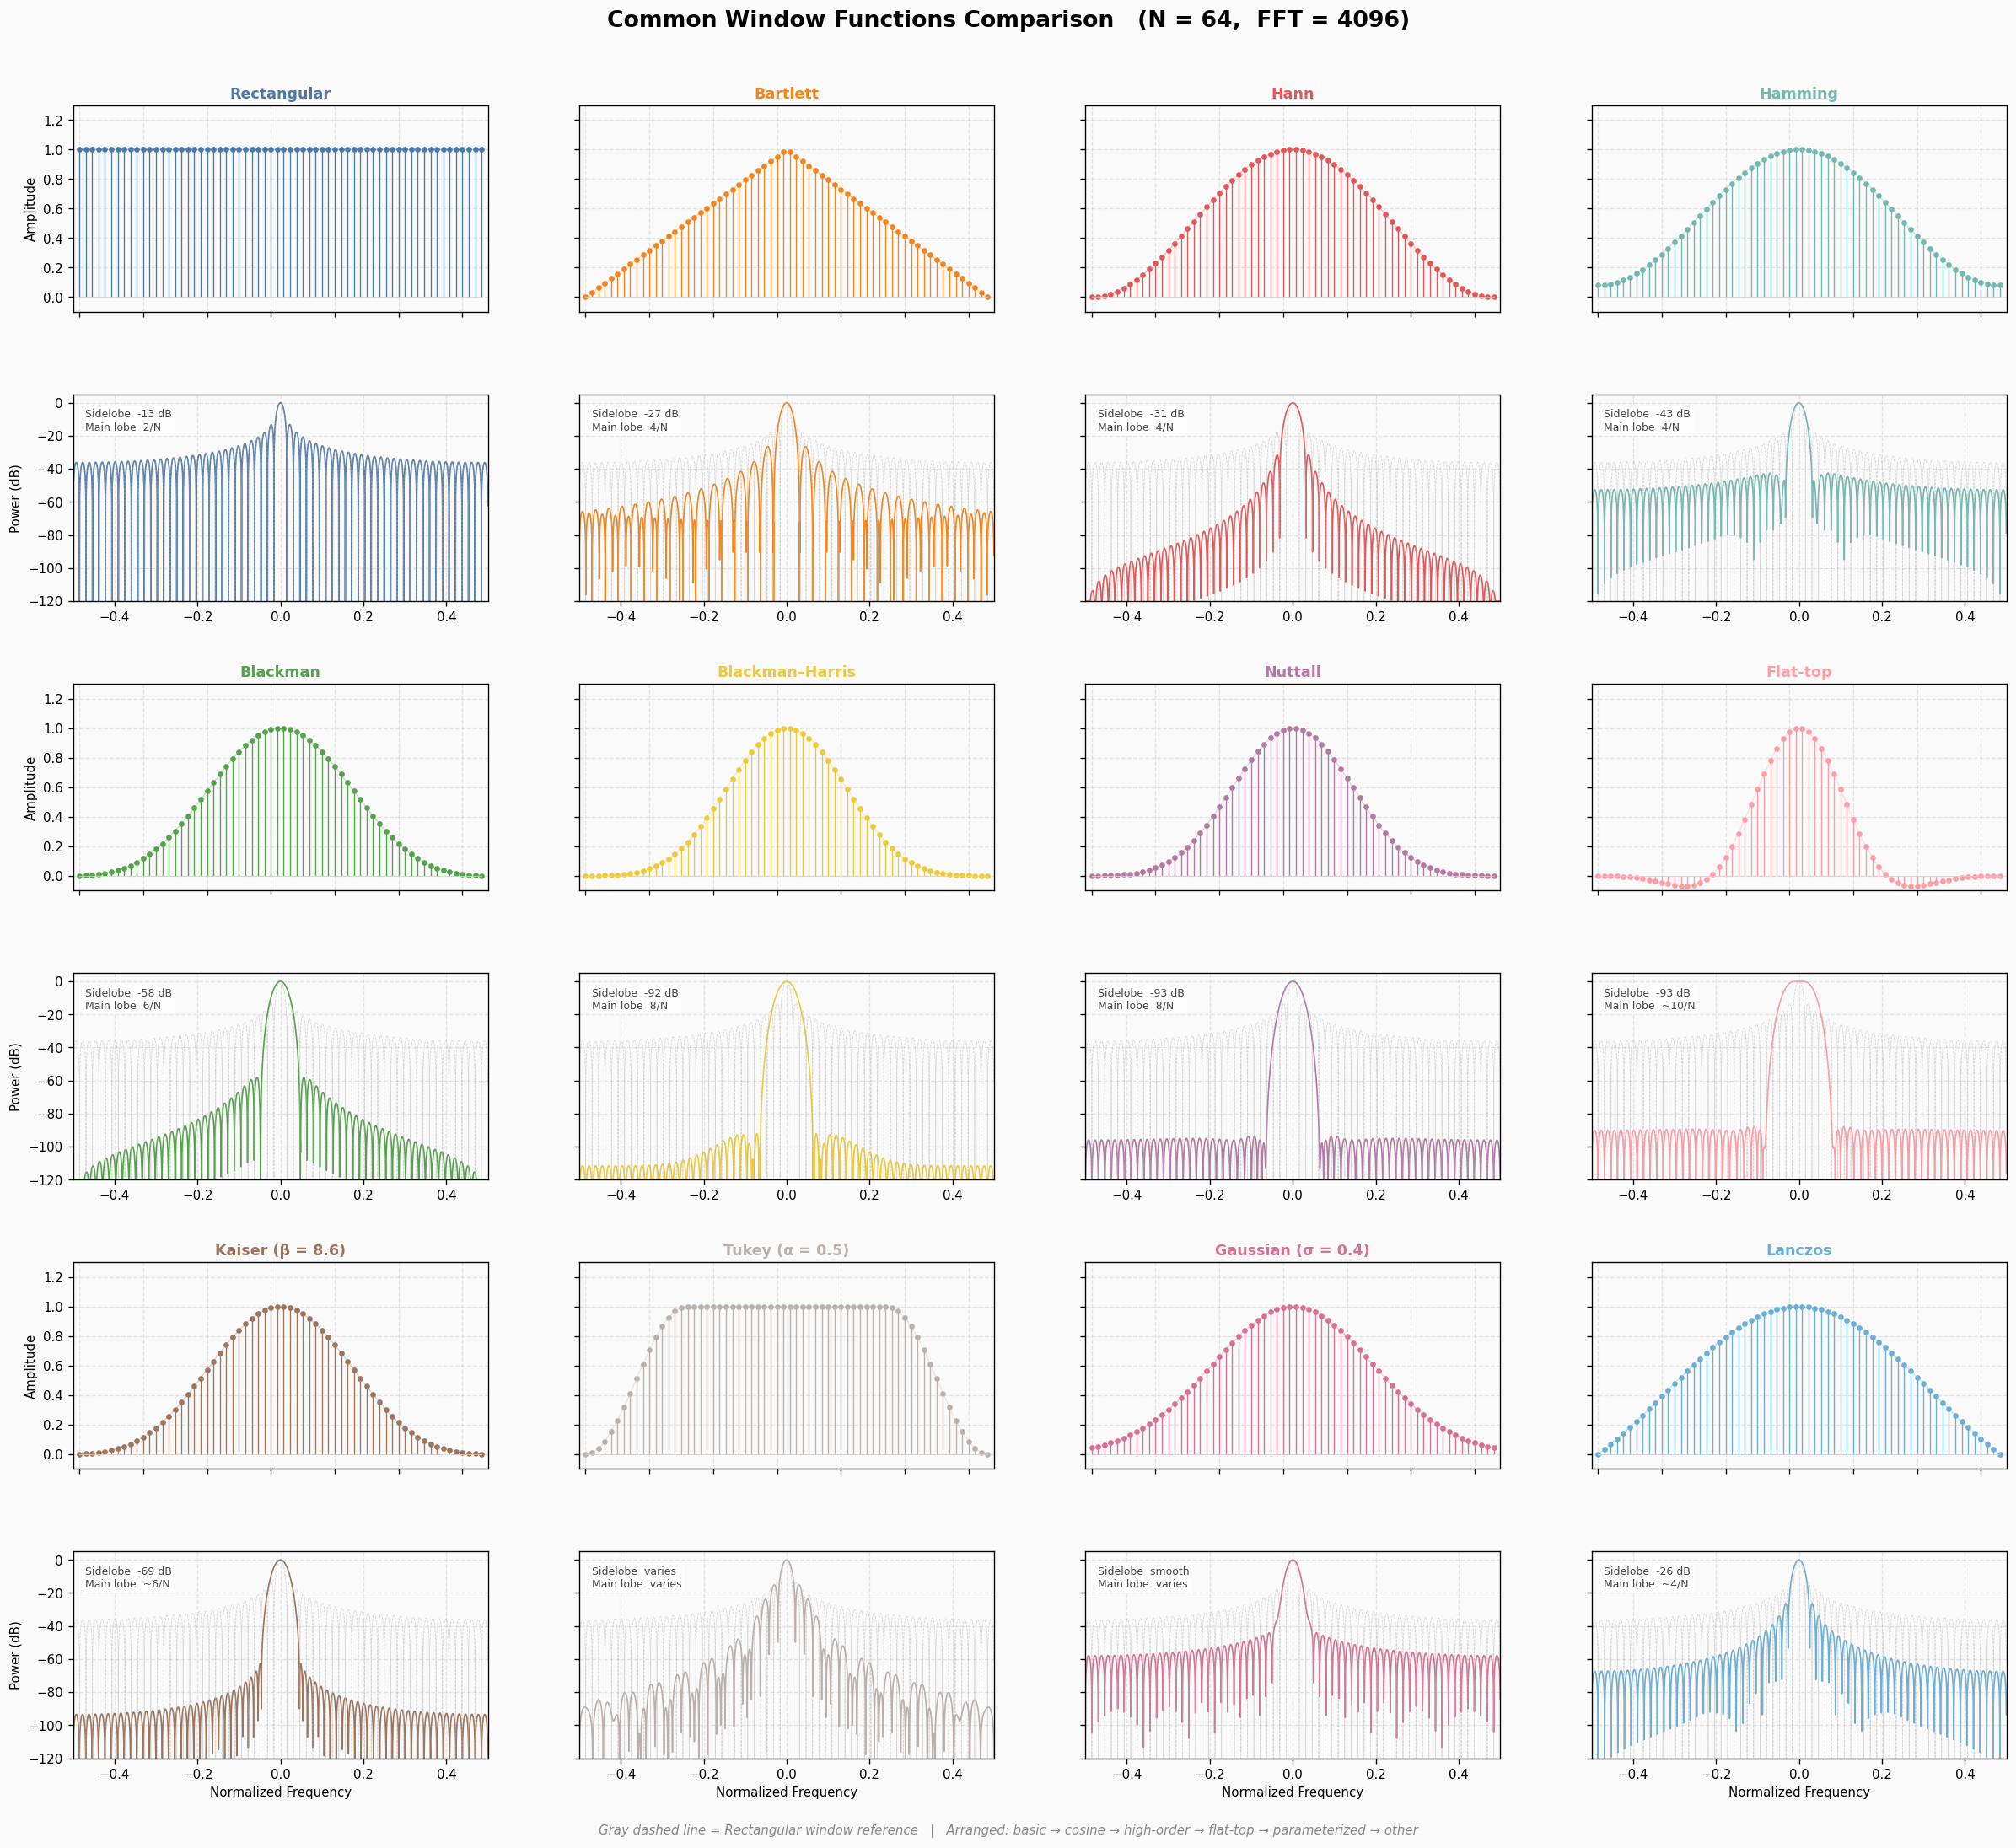

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  样式
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         9,
    "axes.linewidth":    0.8,
    "figure.facecolor":  "#fafafa",
    "axes.facecolor":    "#fafafa",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
})

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  参数
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
N    = 64
NFFT = 4096
n    = np.arange(N)
L    = N - 1
half = L / 2
freq = np.fft.fftshift(np.fft.fftfreq(NFFT))

# ── Tukey 辅助函数 ───────────────────────────────────────
def tukey(N, alpha=0.5):
    n = np.arange(N)
    L = N - 1
    w = np.ones(N)
    m1 = n <= alpha * L / 2
    w[m1] = 0.5 * (1 + np.cos(np.pi * (2 * n[m1] / (alpha * L) - 1)))
    m2 = n >= L * (1 - alpha / 2)
    w[m2] = 0.5 * (1 + np.cos(np.pi * (2 * n[m2] / (alpha * L) - 2 / alpha + 1)))
    return w

# ── 参考频谱（矩形窗，灰色虚线） ─────────────────────────
ref_ps = np.abs(np.fft.fft(np.ones(N), NFFT)) ** 2
ref_db = np.fft.fftshift(10 * np.log10(np.maximum(ref_ps / ref_ps.max(), 1e-12)))

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  12 种窗函数定义
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
windows = [
    # ---- 基本窗 ----
    ("Rectangular",
     np.ones(N)),

    ("Bartlett",
     1 - np.abs(2 * n / L - 1)),

    # ---- 余弦窗 ----
    ("Hann",
     0.5 * (1 - np.cos(2 * np.pi * n / L))),

    ("Hamming",
     0.54 - 0.46 * np.cos(2 * np.pi * n / L)),

    # ---- 高阶余弦窗 ----
    ("Blackman",
     0.42 - 0.5 * np.cos(2 * np.pi * n / L)
         + 0.08 * np.cos(4 * np.pi * n / L)),

    ("Blackman\u2013Harris",
     0.35875 - 0.48829 * np.cos(2 * np.pi * n / L)
             + 0.14128 * np.cos(4 * np.pi * n / L)
             - 0.01168 * np.cos(6 * np.pi * n / L)),

    ("Nuttall",
     0.3635819 - 0.4891775 * np.cos(2 * np.pi * n / L)
               + 0.1365995 * np.cos(4 * np.pi * n / L)
               - 0.0106411 * np.cos(6 * np.pi * n / L)),

    ("Flat-top",
     0.21557895 - 0.41663158 * np.cos(2 * np.pi * n / L)
                + 0.277263158 * np.cos(4 * np.pi * n / L)
                - 0.083578947 * np.cos(6 * np.pi * n / L)
                + 0.006947368 * np.cos(8 * np.pi * n / L)),

    # ---- 参数化窗 ----
    ("Kaiser (\u03b2 = 8.6)",
     np.i0(8.6 * np.sqrt(1 - ((n - half) / half) ** 2)) / np.i0(8.6)),

    ("Tukey (\u03b1 = 0.5)",
     tukey(N, 0.5)),

    ("Gaussian (\u03c3 = 0.4)",
     np.exp(-0.5 * ((n - half) / (0.4 * half)) ** 2)),

    # ---- 其他 ----
    ("Lanczos",
     np.sinc(2 * n / L - 1)),          # np.sinc(x) = sin(πx)/(πx)
]

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  配色 & 旁瓣/主瓣标注
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
colors = [
    "#4c78a8", "#f58518", "#e45756", "#72b7b2",
    "#54a24b", "#eeca3b", "#b279a2", "#ff9da6",
    "#9d755d", "#bab0ac", "#d67195", "#6baed6",
]

meta = {
    "Rectangular":              ("-13 dB",  "2/N"),
    "Bartlett":                 ("-27 dB",  "4/N"),
    "Hann":                     ("-31 dB",  "4/N"),
    "Hamming":                  ("-43 dB",  "4/N"),
    "Blackman":                 ("-58 dB",  "6/N"),
    "Blackman\u2013Harris":     ("-92 dB",  "8/N"),
    "Nuttall":                  ("-93 dB",  "8/N"),
    "Flat-top":                 ("-93 dB",  "~10/N"),
    "Kaiser (\u03b2 = 8.6)":    ("-69 dB",  "~6/N"),
    "Tukey (\u03b1 = 0.5)":     ("varies",  "varies"),
    "Gaussian (\u03c3 = 0.4)":  ("smooth",  "varies"),
    "Lanczos":                  ("-26 dB",  "~4/N"),
}

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  绘图  ─  6 行 × 4 列（每窗 = 时域 + 频域）
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig, axes = plt.subplots(6, 4, figsize=(20, 18), dpi=120)

for idx, (name, w) in enumerate(windows):
    col  = idx % 4
    pair = idx // 4          # 0 / 1 / 2
    ax_t = axes[2 * pair,     col]      # 时域
    ax_f = axes[2 * pair + 1, col]      # 频域
    c    = colors[idx]

    # ── 时域波形 ──
    ml, sl, bl = ax_t.stem(n, w)
    plt.setp(sl,  color=c, linewidth=0.8)
    plt.setp(ml,  color=c, markersize=3)
    plt.setp(bl,  color="lightgray", linewidth=0.5)
    ax_t.plot(n, w, color=c, linewidth=0.8, alpha=0.3)   # 包络连线

    ax_t.set_xlim(-1, N)
    ax_t.set_ylim(-0.1, 1.3)
    ax_t.set_title(name, fontweight="bold", fontsize=10.5, color=c, pad=5)
    ax_t.tick_params(axis="x", labelbottom=False)
    if col > 0:
        ax_t.tick_params(axis="y", labelleft=False)

    # ── 功率谱 (dB) ──
    S    = np.fft.fft(w, NFFT)
    ps   = np.abs(S) ** 2
    psdb = 10 * np.log10(np.maximum(ps / ps.max(), 1e-12))
    ps_s = np.fft.fftshift(psdb)

    ax_f.plot(freq, ps_s,  color=c,       linewidth=1.0, label=name)
    ax_f.plot(freq, ref_db, color="#b0b0b0", linewidth=0.5,
              linestyle="--", alpha=0.5)
    ax_f.set_xlim(-0.5, 0.5)
    ax_f.set_ylim(-120, 5)

    # 标注框
    m = meta.get(name, ("", ""))
    ax_f.text(0.03, 0.93,
              f"Sidelobe  {m[0]}\nMain lobe  {m[1]}",
              transform=ax_f.transAxes, fontsize=7.5, va="top",
              color="#444",
              bbox=dict(boxstyle="round,pad=0.3",
                        fc="white", alpha=0.85, ec="none"))
    if col > 0:
        ax_f.tick_params(axis="y", labelleft=False)

# ── 边缘标签 ─────────────────────────────────────────────
for pair in range(3):
    axes[2 * pair,     0].set_ylabel("Amplitude",  fontsize=9)
    axes[2 * pair + 1, 0].set_ylabel("Power (dB)", fontsize=9)
for col in range(4):
    axes[5, col].set_xlabel("Normalized Frequency")

# ── 底部说明 ─────────────────────────────────────────────
fig.text(0.5, 0.003,
         "Gray dashed line = Rectangular window reference   |   "
         "Arranged: basic \u2192 cosine \u2192 high-order \u2192 "
         "flat-top \u2192 parameterized \u2192 other",
         ha="center", fontsize=9, color="#888", style="italic")

fig.suptitle(
    f"Common Window Functions Comparison   (N = {N},  FFT = {NFFT})",
    fontsize=16, fontweight="bold", y=1.005,
)
plt.tight_layout(rect=[0, 0.015, 1, 0.99])
plt.subplots_adjust(hspace=0.40, wspace=0.22)
plt.show()
